In [1]:
%%writefile dijkstra_benchmark.cpp
#include <iostream>
#include <vector>
#include <queue>
#include <random>
#include <chrono>
#include <fstream>
#include <limits>
#include <utility>

using namespace std;

const int INF = numeric_limits<int>::max();

struct Edge {
    int to;
    int weight;
};

using Graph = vector<vector<Edge>>;

Graph generateGraph(int V, int E) {
    Graph graph(V);
    mt19937 rng(42);
    uniform_int_distribution<int> vertexDist(0, V - 1);
    uniform_int_distribution<int> weightDist(1, 100);

    int added = 0;

    while (added < E) {
        int u = vertexDist(rng);
        int v = vertexDist(rng);

        if (u == v)
            continue;

        int w = weightDist(rng);

        graph[u].push_back({v, w});
        graph[v].push_back({u, w});

        added++;
    }

    return graph;
}

long long dijkstraArray(const Graph& graph, int start, int target) {
    int V = graph.size();

    vector<int> dist(V, INF);
    vector<bool> visited(V, false);

    dist[start] = 0;

    for (int i = 0; i < V; i++) {
        int u = -1;

        for (int v = 0; v < V; v++) {
            if (!visited[v] && dist[v] != INF &&
                (u == -1 || dist[v] < dist[u])) {
                u = v;
            }
        }

        if (u == -1)
            break;

        if (u == target)
            break;

        visited[u] = true;

        for (const auto& edge : graph[u]) {
            int v = edge.to;
            int w = edge.weight;

            if (dist[v] > dist[u] + w)
                dist[v] = dist[u] + w;
        }
    }

    return dist[target];
}

long long dijkstraHeap(const Graph& graph, int start, int target) {
    int V = graph.size();

    vector<int> dist(V, INF);

    priority_queue<pair<int, int>,
                   vector<pair<int, int>>,
                   greater<pair<int, int>>> pq;

    dist[start] = 0;
    pq.push({0, start});

    while (!pq.empty()) {
        auto [d, u] = pq.top();
        pq.pop();

        if (d != dist[u])
            continue;

        if (u == target)
            break;

        for (const auto& edge : graph[u]) {
            int v = edge.to;
            int w = edge.weight;

            if (dist[v] > dist[u] + w) {
                dist[v] = dist[u] + w;
                pq.push({dist[v], v});
            }
        }
    }

    return dist[target];
}

double measureArray(const Graph& graph, int start, int target) {
    auto begin = chrono::high_resolution_clock::now();
    volatile long long result = dijkstraArray(graph, start, target);
    auto end = chrono::high_resolution_clock::now();

    return chrono::duration<double, milli>(end - begin).count();
}

double measureHeap(const Graph& graph, int start, int target) {
    auto begin = chrono::high_resolution_clock::now();
    volatile long long result = dijkstraHeap(graph, start, target);
    auto end = chrono::high_resolution_clock::now();

    return chrono::duration<double, milli>(end - begin).count();
}

int main() {
    ofstream fout("dijkstra_benchmark.csv");

    fout << "Scenario,V,E,Time_Array_ms,Time_Heap_ms\n";

    vector<int> sparseV = {
        1000, 3000, 5000, 7000, 9000,
        11000, 13000, 15000, 17000, 19000
    };

    for (int V : sparseV) {
        int E = 4 * V;

        Graph graph = generateGraph(V, E);

        int start = 0;
        int target = V - 1;

        double timeArray = measureArray(graph, start, target);
        double timeHeap = measureHeap(graph, start, target);

        fout << "Sparse_Graph,"
             << V << ","
             << E << ","
             << timeArray << ","
             << timeHeap << "\n";

        cout << "Sparse: V=" << V
             << ", E=" << E
             << ", Array=" << timeArray << " ms"
             << ", Heap=" << timeHeap << " ms"
             << endl;
    }

    vector<int> denseE = {
        10000, 50000, 200000, 1000000, 3000000
    };

    int V = 3000;

    for (int E : denseE) {
        Graph graph = generateGraph(V, E);

        int start = 0;
        int target = V - 1;

        double timeArray = measureArray(graph, start, target);
        double timeHeap = measureHeap(graph, start, target);

        fout << "Dense_Graph,"
             << V << ","
             << E << ","
             << timeArray << ","
             << timeHeap << "\n";

        cout << "Dense: V=" << V
             << ", E=" << E
             << ", Array=" << timeArray << " ms"
             << ", Heap=" << timeHeap << " ms"
             << endl;
    }

    fout.close();

    return 0;
}


Writing dijkstra_benchmark.cpp


In [2]:
!g++ -O2 dijkstra_benchmark.cpp -o dijkstra_benchmark
!./dijkstra_benchmark


Sparse: V=1000, E=4000, Array=2.73262 ms, Heap=0.315164 ms
Sparse: V=3000, E=12000, Array=17.9085 ms, Heap=0.832414 ms
Sparse: V=5000, E=20000, Array=50.0765 ms, Heap=1.19765 ms
Sparse: V=7000, E=28000, Array=33.4839 ms, Heap=0.619801 ms
Sparse: V=9000, E=36000, Array=313.259 ms, Heap=3.23771 ms
Sparse: V=11000, E=44000, Array=547.883 ms, Heap=5.97808 ms
Sparse: V=13000, E=52000, Array=751.339 ms, Heap=5.21997 ms
Sparse: V=15000, E=60000, Array=1034.49 ms, Heap=6.14053 ms
Sparse: V=17000, E=68000, Array=819.195 ms, Heap=4.26415 ms
Sparse: V=19000, E=76000, Array=1850.47 ms, Heap=11.8023 ms
Dense: V=3000, E=10000, Array=18.2179 ms, Heap=0.862155 ms
Dense: V=3000, E=50000, Array=30.9535 ms, Heap=1.54023 ms
Dense: V=3000, E=200000, Array=27.1399 ms, Heap=2.65707 ms
Dense: V=3000, E=1000000, Array=38.6574 ms, Heap=6.00331 ms
Dense: V=3000, E=3000000, Array=40.0378 ms, Heap=11.7672 ms


In [3]:
!cat dijkstra_benchmark.csv


Scenario,V,E,Time_Array_ms,Time_Heap_ms
Sparse_Graph,1000,4000,2.73262,0.315164
Sparse_Graph,3000,12000,17.9085,0.832414
Sparse_Graph,5000,20000,50.0765,1.19765
Sparse_Graph,7000,28000,33.4839,0.619801
Sparse_Graph,9000,36000,313.259,3.23771
Sparse_Graph,11000,44000,547.883,5.97808
Sparse_Graph,13000,52000,751.339,5.21997
Sparse_Graph,15000,60000,1034.49,6.14053
Sparse_Graph,17000,68000,819.195,4.26415
Sparse_Graph,19000,76000,1850.47,11.8023
Dense_Graph,3000,10000,18.2179,0.862155
Dense_Graph,3000,50000,30.9535,1.54023
Dense_Graph,3000,200000,27.1399,2.65707
Dense_Graph,3000,1000000,38.6574,6.00331
Dense_Graph,3000,3000000,40.0378,11.7672


## Trực quan hóa kết quả

Cell dưới đây đọc `dijkstra_benchmark.csv` được tạo bởi chương trình C++ và vẽ **2 biểu đồ riêng**:
1. Đồ thị thưa: thời gian theo số đỉnh `V`.
2. Đồ thị dày: thời gian theo số cạnh `E`, với trục `E` dùng thang logarit.

Sau khi chạy cell biên dịch/chạy C++, chỉ cần chạy cell vẽ biểu đồ là đồ thị sẽ xuất hiện.

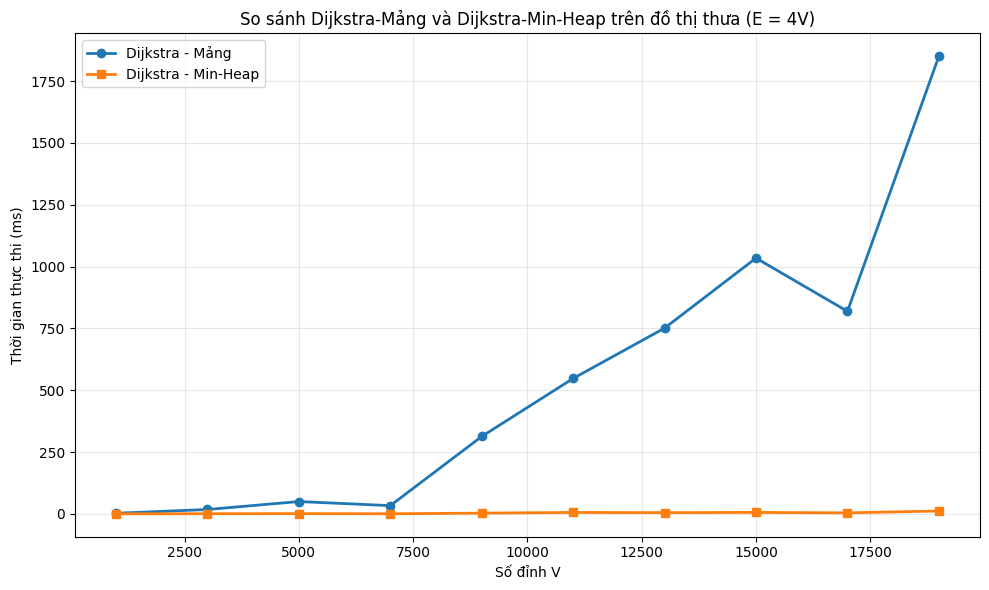

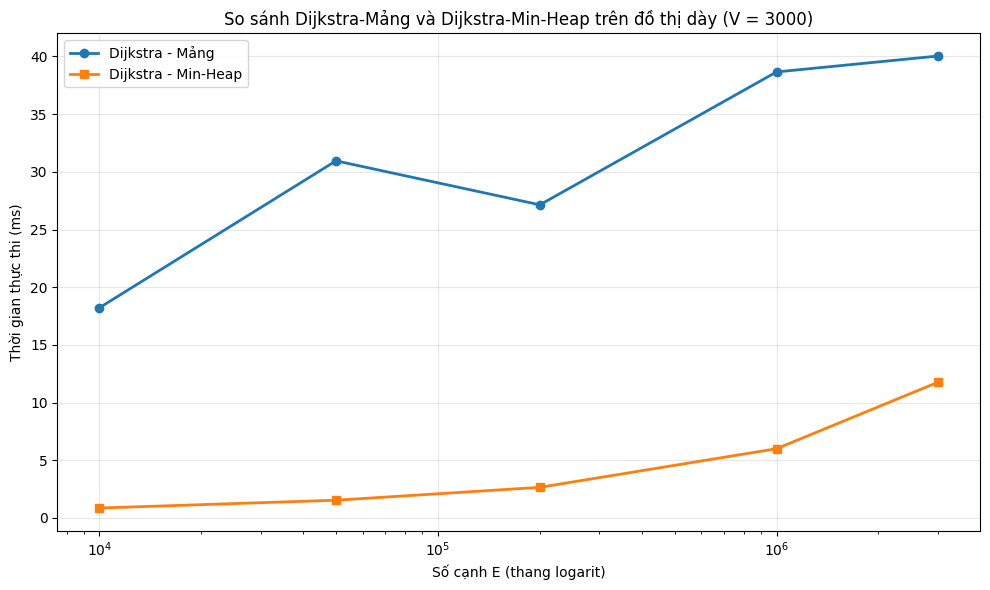

,Scenario,V,E,Time_Array_ms,Time_Heap_ms
0,Sparse_Graph,1000,4000,2.73262,0.315164
1,Sparse_Graph,3000,12000,17.90850,0.832414
2,Sparse_Graph,5000,20000,50.07650,1.197650
3,Sparse_Graph,7000,28000,33.48390,0.619801
4,Sparse_Graph,9000,36000,313.25900,3.237710
5,Sparse_Graph,11000,44000,547.88300,5.978080
6,Sparse_Graph,13000,52000,751.33900,5.219970
7,Sparse_Graph,15000,60000,1034.49000,6.140530
8,Sparse_Graph,17000,68000,819.19500,4.264150
9,Sparse_Graph,19000,76000,1850.47000,11.802300


In [4]:
# ============================================================
# VẼ BIỂU ĐỒ KẾT QUẢ BENCHMARK DIJKSTRA
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

csv_file = "dijkstra_benchmark.csv"

# Đọc dữ liệu benchmark
df = pd.read_csv(csv_file)

# Kiểm tra các cột bắt buộc
required_cols = {
    "Scenario", "V", "E", "Time_Array_ms", "Time_Heap_ms"
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Thiếu cột trong CSV: {sorted(missing)}")

# Chuẩn hóa kiểu dữ liệu
df["V"] = pd.to_numeric(df["V"])
df["E"] = pd.to_numeric(df["E"])
df["Time_Array_ms"] = pd.to_numeric(df["Time_Array_ms"])
df["Time_Heap_ms"] = pd.to_numeric(df["Time_Heap_ms"])

# Tách 2 kịch bản
sparse = df[df["Scenario"] == "Sparse_Graph"].sort_values("V")
dense = df[df["Scenario"] == "Dense_Graph"].sort_values("E")

if sparse.empty:
    raise ValueError("Không tìm thấy dữ liệu Sparse_Graph trong CSV.")
if dense.empty:
    raise ValueError("Không tìm thấy dữ liệu Dense_Graph trong CSV.")

# -------------------- Biểu đồ 1: đồ thị thưa --------------------
plt.figure(figsize=(10, 6))
plt.plot(
    sparse["V"], sparse["Time_Array_ms"],
    marker="o", linewidth=2, label="Dijkstra - Mảng"
)
plt.plot(
    sparse["V"], sparse["Time_Heap_ms"],
    marker="s", linewidth=2, label="Dijkstra - Min-Heap"
)

plt.xlabel("Số đỉnh V")
plt.ylabel("Thời gian thực thi (ms)")
plt.title("So sánh Dijkstra-Mảng và Dijkstra-Min-Heap trên đồ thị thưa (E = 4V)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("dijkstra_sparse.png", dpi=200, bbox_inches="tight")
plt.show()

# -------------------- Biểu đồ 2: đồ thị dày --------------------
plt.figure(figsize=(10, 6))
plt.plot(
    dense["E"], dense["Time_Array_ms"],
    marker="o", linewidth=2, label="Dijkstra - Mảng"
)
plt.plot(
    dense["E"], dense["Time_Heap_ms"],
    marker="s", linewidth=2, label="Dijkstra - Min-Heap"
)

# E trải rộng từ 10 nghìn đến 3 triệu nên dùng log scale
plt.xscale("log")
plt.xlabel("Số cạnh E (thang logarit)")
plt.ylabel("Thời gian thực thi (ms)")
plt.title("So sánh Dijkstra-Mảng và Dijkstra-Min-Heap trên đồ thị dày (V = 3000)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("dijkstra_dense.png", dpi=200, bbox_inches="tight")
plt.show()

# Hiển thị bảng dữ liệu cuối cùng để kiểm tra
display(df)
